In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import MinMaxScaler




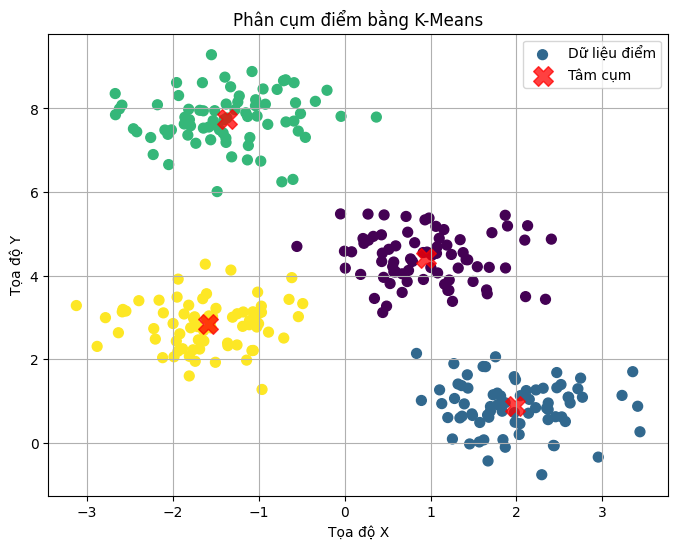

In [ ]:
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)

y_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(8, 6))

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', label='Dữ liệu điểm') 

centers = kmeans.cluster_centers_

plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Tâm cụm')

plt.title("Phân cụm điểm bằng K-Means")
plt.xlabel("Tọa độ X")
plt.ylabel("Tọa độ Y")
plt.legend()
plt.grid(True)
plt.show()




        time    packets     speed
0  32.483571  53.240840  1.639008
1  29.308678  46.149177  1.574591
2  33.238443  43.230780  1.300626
3  37.615149  56.116763  1.491866
4  28.829233  60.309995  2.091974

Cluster Centers:
Cluster 0:
  Time    = 119.41
  Packets = 504.19
  Speed   = 4.29
Cluster 1:
  Time    = 2.08
  Packets = 799.15
  Speed   = 411.82
Cluster 2:
  Time    = 28.87
  Packets = 50.18
  Speed   = 1.78

DDoS Cluster = 1


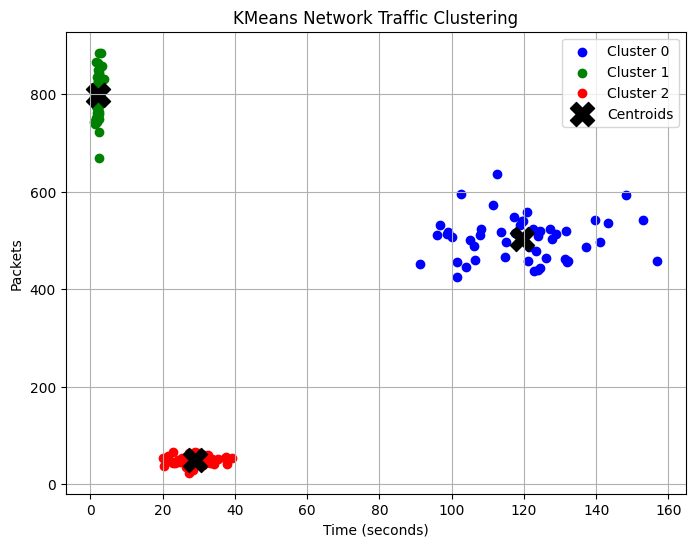


Potential attack traffic:
         time     packets       speed  cluster
100  2.178894  749.564642  344.011573        1
101  2.280392  836.714478  366.916908        1
102  2.541526  884.886248  348.171287        1
103  2.526901  841.298610  332.936906        1
104  1.311165  739.225201  563.792523        1
105  1.531087  780.630637  509.853713        1
106  2.257518  850.676446  376.819403        1
107  2.256893  771.693221  341.927256        1
108  2.257524  817.752777  362.234392        1
109  3.926366  830.985362  211.642373        1


In [13]:
# =========================
# 1. Tạo dataset mô phỏng
# =========================

np.random.seed(42)

# Nhóm người dùng bình thường
normal_time = np.random.normal(30, 5, 50)
normal_packets = np.random.normal(50, 10, 50)
normal_speed = [p / t if t != 0 else 0 for p, t in zip(normal_packets, normal_time)] # Tốc độ = packets / time
# Nhóm máy chủ tải file
server_time = np.random.normal(120, 15, 50)
server_packets = np.random.normal(500, 50, 50)
server_speed = [p / t if t != 0 else 0 for p, t in zip(server_packets, server_time)] # Tốc độ = packets / time

# Nhóm DDoS
ddos_time = np.random.normal(2, 0.5, 50)
ddos_packets = np.random.normal(800, 40, 50)
ddos_speed = [p / t if t != 0 else 0 for p, t in zip(ddos_packets, ddos_time)] # Tốc độ = packets / time

# Ghép dữ liệu
time_data = np.concatenate([
    normal_time,
    server_time,
    ddos_time
])

packet_data = np.concatenate([
    normal_packets,
    server_packets,
    ddos_packets
])
speed_data = np.concatenate([
    normal_speed,
    server_speed,
    ddos_speed
])
# DataFrame
df = pd.DataFrame({
    'time': time_data,
    'packets': packet_data,
    'speed': speed_data
})

print(df.head())

# =========================
# 2. Chuẩn hóa dữ liệu
# =========================

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df) # Chuẩn hóa dữ liệu về khoảng [0, 1]

# =========================
# 3. KMeans Clustering
# =========================

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df['cluster'] = kmeans.fit_predict(scaled_data) # Thêm cột cluster vào DataFrame gốc, dựa trên dữ liệu đã chuẩn hóa, gán nhãn cluster vào DataFrame gốc để dễ dàng phân tích sau này.

# =========================
# 4. Tâm cụm
# =========================

centers = scaler.inverse_transform(
    kmeans.cluster_centers_
) # Chuyển đổi tâm cụm từ không gian chuẩn hóa về không gian gốc để dễ hiểu hơn.

print("\nCluster Centers:")
for i, center in enumerate(centers):
    print(f"Cluster {i}:")
    print(f"  Time    = {center[0]:.2f}")
    print(f"  Packets = {center[1]:.2f}")
    print(f"  Speed   = {center[2]:.2f}")

# =========================
# 5. Xác định cluster DDoS
# =========================

# cluster có packet lớn nhất
ddos_cluster = np.argmax(centers[:, 1])

print(f"\nDDoS Cluster = {ddos_cluster}")

# =========================
# 6. Visualize
# =========================

plt.figure(figsize=(8, 6))

colors = ['blue', 'green', 'red']

for cluster_id in range(3):
    cluster_points = df[df['cluster'] == cluster_id] # Lọc các điểm thuộc cluster hiện tại để vẽ chúng với màu sắc khác nhau.

    plt.scatter(
        cluster_points['time'],
        cluster_points['packets'],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}'
    )

# Vẽ centroid
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='black',
    marker='X',
    s=300,
    label='Centroids'
)

plt.xlabel('Time (seconds)')
plt.ylabel('Packets')
plt.title('KMeans Network Traffic Clustering')

plt.legend()
plt.grid(True)

plt.show()

# =========================
# 7. Cảnh báo
# =========================

print("\nPotential attack traffic:")

attack_data = df[df['cluster'] == ddos_cluster]

print(attack_data.head(10))
